In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from metpy.calc import find_peaks
from metpy.calc import smooth_gaussian
from metpy.units import units

In [27]:
from pathlib import Path

DATA_DIR = Path("../data")
IN_NAME = "msl_2021novdec.nc"

def wrap_lon_to_180(lon_1d: np.ndarray) -> np.ndarray:
    lon = np.asarray(lon_1d, dtype=np.float64)
    return ((lon + 180.0) % 360.0) - 180.0

ds = xr.open_dataset(DATA_DIR / IN_NAME)

# time coord name (match your file)
if "valid_time" in ds.coords:
    tcoord = "valid_time"
elif "time" in ds.coords:
    tcoord = "time"
else:
    raise KeyError(f"No 'valid_time' or 'time' coord. Coords: {list(ds.coords)}")

if "msl" not in ds.data_vars:
    raise KeyError(f"No 'msl' var. Data vars: {list(ds.data_vars)}")

if "latitude" not in ds.coords or "longitude" not in ds.coords:
    raise KeyError(f"Need 'latitude' and 'longitude' coords. Coords: {list(ds.coords)}")

lat = ds["latitude"].values.astype(np.float64)
lon_raw = ds["longitude"].values
lon = wrap_lon_to_180(lon_raw)
lon_order = np.argsort(lon)
lon_sorted = lon[lon_order].astype(np.float64)

times = ds[tcoord].values
print("time coord:", tcoord, "| n_times:", len(times))
print("first:", times[0], "last:", times[-1])

time coord: valid_time | n_times: 1464
first: 2021-11-01T00:00:00.000000000 last: 2021-12-31T23:00:00.000000000


In [28]:
# Pick a timestep by index (fastest and safest).
# Example: 0, 1, 2... or set to whatever you want to inspect.
TIME_INDEX = 0

t64 = times[TIME_INDEX]
tstamp = np.datetime_as_string(np.datetime64(t64), unit="s")
print("chosen time:", tstamp)

# Load only one time step, then reorder longitude axis
msl_pa = ds["msl"].isel({tcoord: TIME_INDEX}).values  # (lat, lon) Pa
msl_pa = msl_pa[:, lon_order].astype(np.float64)

# Convert to hPa
msl_hpa = (msl_pa * units.pascal).to("hPa").magnitude

print("msl hPa range:", float(np.nanmin(msl_hpa)), "to", float(np.nanmax(msl_hpa)))

chosen time: 2021-11-01T00:00:00
msl hPa range: 947.67375 to 1045.28625


In [29]:
# For ERA5 0.5°, sigma=1.0 is a decent starting point.
SMOOTH_SIGMA = 1.0
msl_hpa_smooth = smooth_gaussian(msl_hpa, n=SMOOTH_SIGMA)

In [30]:
# Larger iqr_ratio => fewer centers (more synoptic)
IQR_RATIO = 20.0

hy, hx = find_peaks(msl_hpa_smooth, maxima=True,  iqr_ratio=IQR_RATIO)   # highs
ly, lx = find_peaks(msl_hpa_smooth, maxima=False, iqr_ratio=IQR_RATIO)   # lows

print("highs:", len(hx), "lows:", len(lx))

high_lats = lat[hy]
high_lons = lon_sorted[hx]
low_lats  = lat[ly]
low_lons  = lon_sorted[lx]

high_vals = msl_hpa[hy, hx]
low_vals  = msl_hpa[ly, lx]

highs: 30 lows: 43


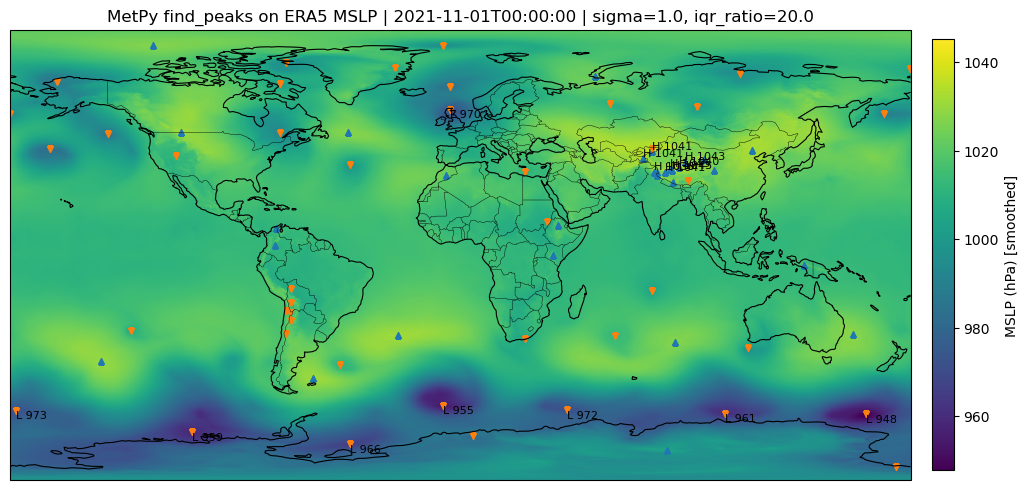

In [31]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=proj)

ax.set_global()
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.08)
ax.add_feature(cfeature.OCEAN, alpha=0.02)

im = ax.pcolormesh(
    lon_sorted, lat, msl_hpa_smooth,
    transform=proj, shading="auto"
)

cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label("MSLP (hPa) [smoothed]")

ax.scatter(high_lons, high_lats, s=18, marker="^", transform=proj)
ax.scatter(low_lons,  low_lats,  s=18, marker="v", transform=proj)

# Label strongest few
N_LABEL = 8

if len(high_vals) > 0:
    idx = np.argsort(high_vals)[::-1][:N_LABEL]
    for k in idx:
        ax.text(high_lons[k], high_lats[k], f"H {high_vals[k]:.0f}",
                transform=proj, fontsize=8, ha="left", va="bottom")

if len(low_vals) > 0:
    idx = np.argsort(low_vals)[:N_LABEL]
    for k in idx:
        ax.text(low_lons[k], low_lats[k], f"L {low_vals[k]:.0f}",
                transform=proj, fontsize=8, ha="left", va="top")

ax.set_title(f"MetPy find_peaks on ERA5 MSLP | {tstamp} | sigma={SMOOTH_SIGMA}, iqr_ratio={IQR_RATIO}")
plt.show()

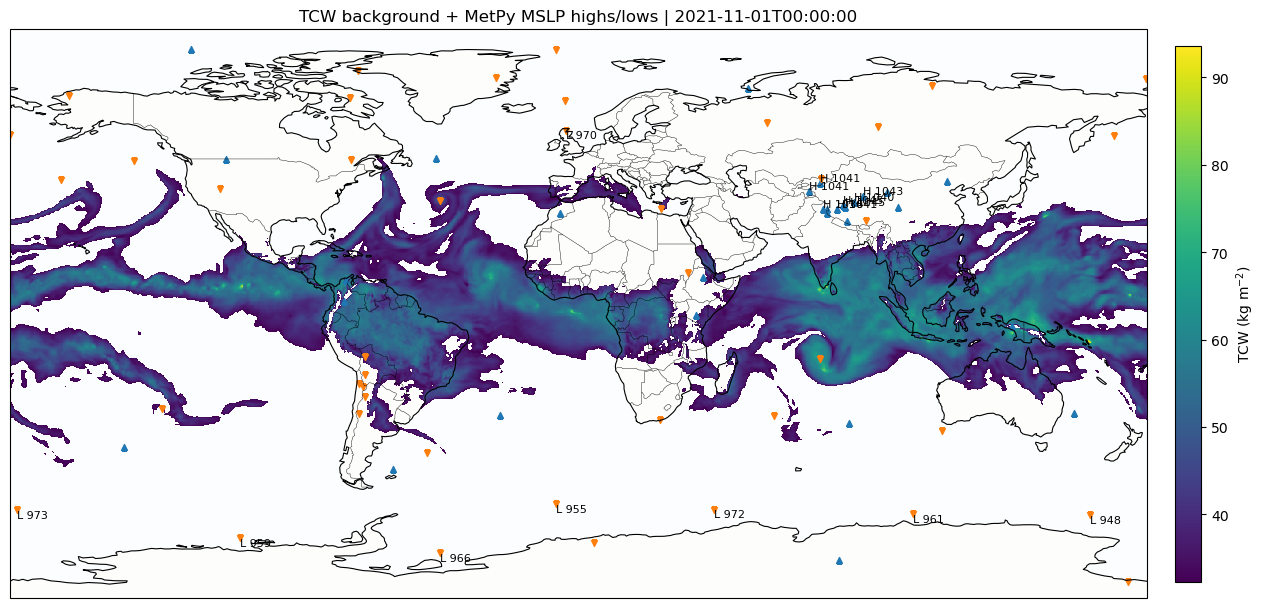

In [35]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------
# 1) Load TCW for the same time
# ----------------------------
TCW_PATH = "../data/waterTransport-instant.nc"
ds_tcw = xr.open_dataset(TCW_PATH)

# variable name: you used "tcw"
da_tcw = ds_tcw["tcw"]

# choose time coord (match ERA5 naming patterns)
if "valid_time" in da_tcw.coords:
    tcoord_tcw = "valid_time"
elif "time" in da_tcw.coords:
    tcoord_tcw = "time"
else:
    raise KeyError(f"TCW has no valid_time/time coord. Coords: {list(da_tcw.coords)}")

# If t64 exists from the previous MSLP cell, use it.
# Otherwise, set it manually:
# t64 = np.datetime64("2021-11-13T12:00:00")

tcw = da_tcw.sel({tcoord_tcw: np.datetime64(t64)})

# ----------------------------
# 2) Standardize lon/lat to match your MSLP lon wrapping/sorting
#    so overlays line up cleanly
# ----------------------------
def wrap_lon_to_180(lon_1d: np.ndarray) -> np.ndarray:
    lon = np.asarray(lon_1d, dtype=np.float64)
    return ((lon + 180.0) % 360.0) - 180.0

# coordinate names
lon_name = "longitude" if "longitude" in tcw.coords else "lon"
lat_name = "latitude" if "latitude" in tcw.coords else "lat"

lon_raw = tcw[lon_name].values
lat = tcw[lat_name].values.astype(np.float64)

lon = wrap_lon_to_180(lon_raw)
lon_order = np.argsort(lon)
lon_sorted = lon[lon_order].astype(np.float64)

# reorder tcw to match sorted lons
tcw_vals = tcw.values
# tcw should be (lat, lon) for a single timestep
tcw_vals = tcw_vals[:, lon_order].astype(np.float64)

# ----------------------------
# 3) Plot TCW background + MetPy highs/lows overlay
# ----------------------------
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=proj)

ax.set_global()
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.08)
ax.add_feature(cfeature.OCEAN, alpha=0.02)

# --- keep only top 20% (filter out bottom 80%) ---
q = np.nanquantile(tcw_vals, 0.80)   # 80th percentile threshold
tcw_masked = np.ma.masked_less(tcw_vals, q)

# then plot tcw_masked instead of tcw_vals
im = ax.pcolormesh(
    lon_sorted, lat, tcw_masked,
    transform=proj, shading="auto"
)

cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.set_label("TCW (kg m$^{-2}$)")

# Overlay highs/lows computed from MSLP earlier
ax.scatter(high_lons, high_lats, s=18, marker="^", transform=proj)
ax.scatter(low_lons,  low_lats,  s=18, marker="v", transform=proj)

# Label strongest few (based on MSLP values from the prior cell)
N_LABEL = 8

if len(high_vals) > 0:
    idx = np.argsort(high_vals)[::-1][:N_LABEL]
    for k in idx:
        ax.text(
            high_lons[k], high_lats[k], f"H {high_vals[k]:.0f}",
            transform=proj, fontsize=8, ha="left", va="bottom"
        )

if len(low_vals) > 0:
    idx = np.argsort(low_vals)[:N_LABEL]
    for k in idx:
        ax.text(
            low_lons[k], low_lats[k], f"L {low_vals[k]:.0f}",
            transform=proj, fontsize=8, ha="left", va="top"
        )

tstamp = np.datetime_as_string(np.datetime64(t64), unit="s")
ax.set_title(f"TCW background + MetPy MSLP highs/lows | {tstamp}")

plt.tight_layout()
plt.show()